# Exploratory Data Analysis: Bivariate

## 1. Import packages

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

## 2. Load data

Load the merged data set `merged_final.csv` and get familiar with it.

In [2]:

df = pd.read_csv("../data/merged_final.csv")
df.head()

,year,StateAbbr,County name,CountyFIPS,BPHIGH,CASTHMA,COPD,MHLTH,PHLTH,SLEEP,...,pct_graduate_degree,pct_less_than_hs,pct_white,pct_black,pct_asian,pct_hispanic,median_household_income,state,county_x,climate_type_short
0,2013,AK,ANCHORAGE MUNICIPALITY ...,2020,28.691667,NaN,NaN,NaN,NaN,NaN,...,92.5,23.2,0.1,7.9,7.8,92.0,77454,2,20,ET
1,2013,AL,JEFFERSON COUNTY ...,1073,41.893750,NaN,NaN,NaN,NaN,NaN,...,87.4,26.6,0.1,0.8,0.8,96.2,45429,1,73,Cfa
2,2013,AL,MADISON COUNTY ...,1089,37.654348,NaN,NaN,NaN,NaN,NaN,...,90.0,21.4,0.1,2.3,2.2,95.4,58434,1,89,Cfa
3,2013,AL,MOBILE COUNTY ...,1097,44.833333,NaN,NaN,NaN,NaN,NaN,...,83.9,33.0,0.0,1.4,1.4,97.5,43028,1,97,Cfa
4,2013,AL,MONTGOMERY COUNTY ...,1101,39.792727,NaN,NaN,NaN,NaN,NaN,...,85.6,26.2,0.1,1.3,1.1,96.5,44790,1,101,Cfa


## 3. Wrangle and inspect data

### 3.1. Pivot to wider format

In [ ]:
# no longer needed so commenting out

# measure_specific = ['measureid_c', 'measure_c', 'data_value_c', 'low_confidence_limit_c',
#                    'high_confidence_limit_c', 'category_c', 'categoryid_c', 'short_question_text_c']
# index_cols = [c for c in df.columns if c not in measure_specific]

# df_pivot = df.pivot(
#    index=index_cols,
#    columns='measureid_c',
#    values=['data_value_c', 'low_confidence_limit_c', 'high_confidence_limit_c']
# ).reset_index()

# df_pivot.columns = [''.join(col).strip('') if isinstance(col, tuple) else col for col in df_pivot.columns]

# print(df_pivot.shape)
# df_pivot.head()

(1818, 70)


,year,stateabbr_c,statedesc_c,locationname_c,locationid_c,totalpopulation_c,geolocation_c,sca_release_id_c,msa_c,msa_code,...,low_confidence_limit_cPHLTH,low_confidence_limit_cSTROKE,high_confidence_limit_cCASTHMA,high_confidence_limit_cCHD,high_confidence_limit_cCOPD,high_confidence_limit_cLPA,high_confidence_limit_cMHLTH,high_confidence_limit_cOBESITY,high_confidence_limit_cPHLTH,high_confidence_limit_cSTROKE
0,2014,AK,Alaska,Anchorage,203000,"291,826","(61.149868731, -149.111113424)",2014_500_Cities_2016_release,"Anchorage, AK Metro Area",112.0,...,9.8,2.6,8.6,5.1,5.1,19.5,9.5,27.9,10.1,2.6
1,2014,AL,Alabama,Birmingham,107000,"212,237","(33.5275663773, -86.7988174678)",2014_500_Cities_2016_release,"Birmingham, AL Metro Area",136.0,...,18.0,5.0,11.5,7.7,9.6,32.1,17.2,39.1,18.5,5.1
2,2014,AL,Alabama,Huntsville,137000,"180,105","(34.6989692671, -86.6387042882)",2014_500_Cities_2016_release,"Huntsville, AL Metro Area",259.0,...,13.7,3.1,9.7,6.8,7.7,25.3,14.2,32.2,14.2,3.2
3,2014,AL,Alabama,Mobile,150000,"195,111","(30.6776248648, -88.1184482714)",2014_500_Cities_2016_release,"Mobile, AL Metro Area",333.0,...,16.1,4.0,10.8,7.7,8.8,27.8,16.0,37.8,16.5,4.1
4,2014,AL,Alabama,Montgomery,151000,"205,764","(32.3472645333, -86.2677059552)",2014_500_Cities_2016_release,"Montgomery, AL Metro Area",337.0,...,16.0,4.0,10.9,7.3,8.8,28.3,15.7,37.1,16.4,4.1


### 3.2. Inspect data set

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6646 entries, 0 to 6645
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     6646 non-null   int64  
 1   StateAbbr                6646 non-null   str    
 2   County name              6646 non-null   str    
 3   CountyFIPS               6646 non-null   int64  
 4   BPHIGH                   6031 non-null   float64
 5   CASTHMA                  6322 non-null   float64
 6   COPD                     6322 non-null   float64
 7   MHLTH                    6322 non-null   float64
 8   PHLTH                    6322 non-null   float64
 9   SLEEP                    5881 non-null   float64
 10  STROKE                   6322 non-null   float64
 11  STATION                  6601 non-null   str    
 12  NAME_x                   6601 non-null   str    
 13  LATITUDE                 6601 non-null   float64
 14  LONGITUDE                6601 non-n

In [4]:
df.describe()

,year,CountyFIPS,BPHIGH,CASTHMA,COPD,MHLTH,PHLTH,SLEEP,STROKE,LATITUDE,...,pct_bachelors_plus,pct_graduate_degree,pct_less_than_hs,pct_white,pct_black,pct_asian,pct_hispanic,median_household_income,state,county_x
count,6646.000000,6646.000000,6031.000000,6322.000000,6322.000000,6322.000000,6322.000000,5881.000000,6322.000000,6601.000000,...,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000,6646.000000
mean,2019.442221,29337.735781,32.697463,9.959085,7.050820,15.249113,12.677618,34.745777,3.341382,38.847586,...,15.372359,35.602498,13.560563,42.071742,17.114430,3.435134,22.217409,60821.614956,29.249774,87.961481
std,2.724670,16482.327140,5.222663,1.273695,1.737643,2.773925,2.565440,4.313941,0.740039,6.330642,...,6.516026,36.799622,10.838375,36.470274,29.592493,6.124067,29.929215,16229.381087,16.464584,97.335341
min,2013.000000,1003.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.535400,...,0.700000,0.200000,0.500000,0.000000,0.000000,0.000000,0.000000,23132.000000,1.000000,1.000000
25%,2018.000000,16037.000000,29.650000,9.229029,5.850000,13.500000,11.000000,31.900000,2.900000,34.348330,...,10.600000,7.600000,5.500000,1.700000,0.900000,0.800000,2.900000,49892.250000,16.000000,27.000000
50%,2020.000000,30029.000000,32.500000,10.000000,6.950000,15.300000,12.650000,34.650000,3.300000,39.229940,...,14.500000,12.600000,8.100000,44.900000,2.600000,1.700000,7.200000,57589.500000,30.000000,63.000000
75%,2022.000000,45063.000000,35.400000,10.700000,8.150000,17.100000,14.300000,37.650000,3.700000,42.590187,...,19.600000,85.400000,23.000000,78.200000,13.600000,3.400000,25.700000,68497.500000,45.000000,113.000000
max,2023.000000,56045.000000,52.200000,15.350000,16.000000,26.200000,24.320995,49.632282,7.662379,71.287030,...,45.400000,98.400000,53.100000,100.000000,100.000000,72.700000,99.000000,178707.000000,56.000000,810.000000


In [5]:
df.head(5)

,year,StateAbbr,County name,CountyFIPS,BPHIGH,CASTHMA,COPD,MHLTH,PHLTH,SLEEP,...,pct_graduate_degree,pct_less_than_hs,pct_white,pct_black,pct_asian,pct_hispanic,median_household_income,state,county_x,climate_type_short
0,2013,AK,ANCHORAGE MUNICIPALITY ...,2020,28.691667,NaN,NaN,NaN,NaN,NaN,...,92.5,23.2,0.1,7.9,7.8,92.0,77454,2,20,ET
1,2013,AL,JEFFERSON COUNTY ...,1073,41.893750,NaN,NaN,NaN,NaN,NaN,...,87.4,26.6,0.1,0.8,0.8,96.2,45429,1,73,Cfa
2,2013,AL,MADISON COUNTY ...,1089,37.654348,NaN,NaN,NaN,NaN,NaN,...,90.0,21.4,0.1,2.3,2.2,95.4,58434,1,89,Cfa
3,2013,AL,MOBILE COUNTY ...,1097,44.833333,NaN,NaN,NaN,NaN,NaN,...,83.9,33.0,0.0,1.4,1.4,97.5,43028,1,97,Cfa
4,2013,AL,MONTGOMERY COUNTY ...,1101,39.792727,NaN,NaN,NaN,NaN,NaN,...,85.6,26.2,0.1,1.3,1.1,96.5,44790,1,101,Cfa


In [6]:
df.isnull().sum()

year                          0
StateAbbr                     0
County name                   0
CountyFIPS                    0
BPHIGH                      615
CASTHMA                     324
COPD                        324
MHLTH                       324
PHLTH                       324
SLEEP                       765
STROKE                      324
STATION                      45
NAME_x                       45
LATITUDE                     45
LONGITUDE                    45
ELEVATION                    45
CLDD                        521
DT100                      6646
DT32                        491
DX32                        484
DX70                        484
DX90                        484
EMNT                        491
EMXT                        484
HTDD                        535
PRCP                        565
TAVG                        512
TMAX                        484
TMIN                        491
COUNTY                       45
ST                           45
Matched 

How NAs are distributed:
* **Dozens of NAs**: `STATION`, `NAME_x`, `LATITUDE`, `LONGITUDE`, `ELEVATION`, `COUNTY`, `ST`, `Matched County`
* **Hundreds of NAs**:  `BPHIGH`, `CASTHMA`, `COPD`, `MHLTH`, `SLEEP`, `STROKE`, `CLDD`, `DT32`, `DX32`, `DX70`, `DX90`, `EMNT`, `EMXT`, `HTDD`, `PRCP`, `TAVG`, `TMAX`, `TMIN`
* **Thousands of NAs**: `Matched County_x`, `CountyFIPS_x`, `Matched County_y`, `County_FIPS_y`

## 4. Visualize bivariate relationships I: Health vs. weather

### 4.1. Compute a correlation matrix and plot the heatmap

We start by selecting specific weather variables as independent variables, as well as specific health outcomes. We select those specific health outcomes because they are the ones most likely to be sensitive to the environment:
* **Respiratory (asthma, COPD):** Lungs are responsive to air. Cold air and humidity are famous triggers for attacks.
* **Cardiovascular (heart Disease, stroke):** Extreme temperatures force the heart to work harder to cool the body down or warm it up, which can lead to "events" in vulnerable populations.
* **Cumulative effects (obesity, physical, and mental health):** These can reflect quality of life. For example, if extreme heat persists, people can't exercise (physical health, obesity) and often feel isolated (mental health).


In [3]:
weather_vars = ['TAVG', 'TMIN', 'TMAX', 'CLDD', 'HTDD', 'DX90', 'DX32', 'DT32', 'PRCP']
health_vars = ['CASTHMA', 'SLEEP', 'COPD', 
               'MHLTH', 'PHLTH', 'STROKE', 'BPHIGH']

Then, we create a correlation matrix which runs a Pearson Correlation for each possible pair. We use `.dropna()` here to ensure we only correlate rows that have both weather and health data. In other words, `.dropna()` keeps only rows where _all_ 10 variables are non-missing.

In [4]:
corr_matrix = df[weather_vars + health_vars].dropna().corr()
corr_subset = corr_matrix.loc[weather_vars, health_vars]

print('Shape of data set containing NAs:', df[weather_vars + health_vars].shape)
print('Shape of data set excluding NAs:', df[weather_vars + health_vars].dropna().shape)
print(corr_subset)

Shape of data set containing NAs: (6646, 16)
Shape of data set excluding NAs: (4309, 16)
       CASTHMA     SLEEP      COPD     MHLTH     PHLTH    STROKE    BPHIGH
TAVG -0.186649  0.431442  0.085177  0.216145  0.202069  0.183325  0.370905
TMIN -0.182571  0.456005  0.078301  0.192134  0.168562  0.160456  0.371631
TMAX -0.179981  0.381945  0.087235  0.227996  0.224231  0.195750  0.348898
CLDD -0.259376  0.417429  0.075242  0.152325  0.196193  0.198446  0.347418
HTDD  0.145761 -0.426124 -0.089909 -0.233008 -0.205972 -0.177820 -0.358254
DX90 -0.221271  0.284400  0.044494  0.161020  0.243730  0.207239  0.266850
DX32  0.036657 -0.301929 -0.060567 -0.213973 -0.150797 -0.093209 -0.254864
DT32  0.128472 -0.414664 -0.045491 -0.212592 -0.171599 -0.146673 -0.332514
PRCP  0.039919  0.332242  0.233258  0.100112  0.070291  0.163935  0.383067


To visualize the relationships, we can create a heatmap, or, a "Weather-Health" map (retaining only correlations between weather and health variables, and not autocorrelations).

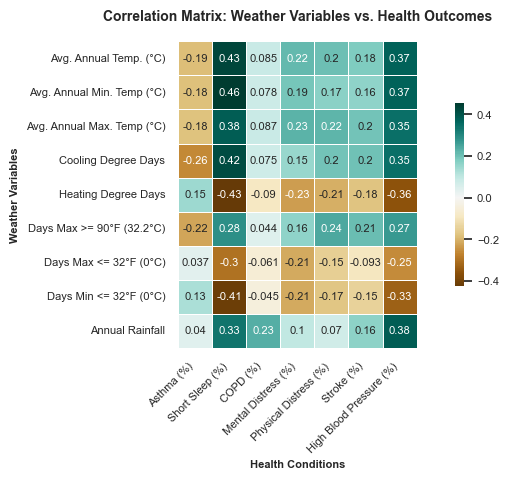

In [5]:
rename_dict = {
    'TAVG': 'Avg. Annual Temp. (°C)',
    'DX90': 'Days Max >= 90°F (32.2°C)',
    'DT32': 'Days Min <= 32°F (0°C)',
    'PRCP': 'Annual Rainfall',
    'HTDD': 'Heating Degree Days',
    'CLDD': 'Cooling Degree Days',
    'DX32': 'Days Max <= 32°F (0°C)',
    'TMIN': 'Avg. Annual Min. Temp (°C)',
    'TMAX': 'Avg. Annual Max. Temp (°C)',
    'CASTHMA': 'Asthma (%)',
    'SLEEP': 'Short Sleep (%)',
    'COPD': 'COPD (%)',
    'MHLTH': 'Mental Distress (%)',
    'PHLTH': 'Physical Distress (%)',
    'STROKE': 'Stroke (%)',
    'BPHIGH': 'High Blood Pressure (%)'
}

corr_plot = corr_subset.rename(index=rename_dict, columns=rename_dict)

sns.set(style="white", font_scale=1.1)
plt.figure(figsize=(8, 5))

ax = sns.heatmap(
    corr_plot,
    annot=True,
    cmap="BrBG",
    center=0,
    square=True,          
    linewidths=.5, 
    cbar_kws={"shrink": .6, "pad": 0.05}, 
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix: Weather Variables vs. Health Outcomes",
          fontsize=10, weight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.xlabel("Health Conditions", fontsize=8, weight='bold')
plt.ylabel("Weather Variables", fontsize=8, weight='bold')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

Inside the squares, we can see Pearson's correlation coefficient for each pair of variables.

It seems that all associations are weak to moderate.

### 4.2. Create scatter plots to visualize relationships

For this visualization, we will choose to portray 3 specific relationships:

* **Frost Days vs. Sleep:** `DT32` (annual count of frost days) vs. `SLEEP` (the model-based estimate of the percentage of adults who report short sleep duration).
* **Annual Precipitation vs. High BP:** `PRCP` (the cumulative liquid-equivalent measurement of all forms of precipitation recorded over a year) vs. `BPHIGH` (the model-based estimate of the percentage of adults who report high blood pressure).
* **High Avg Temp vs. Sleep:** `TAVG` (average annual temperature) vs. `SLEEP`.

We selected these 3 pairs because they represent the strongest statistical correlations between environmental stressors and health outcomes within the dataset.

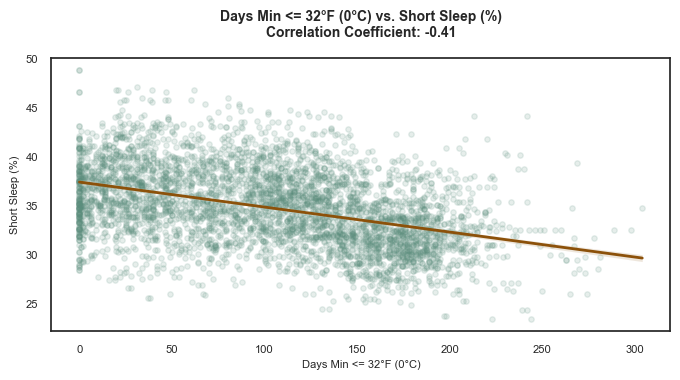

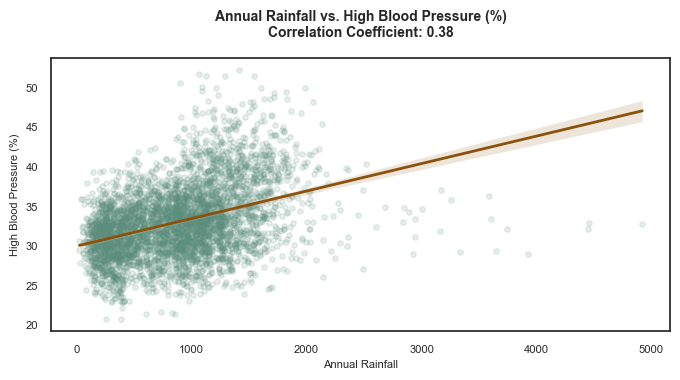

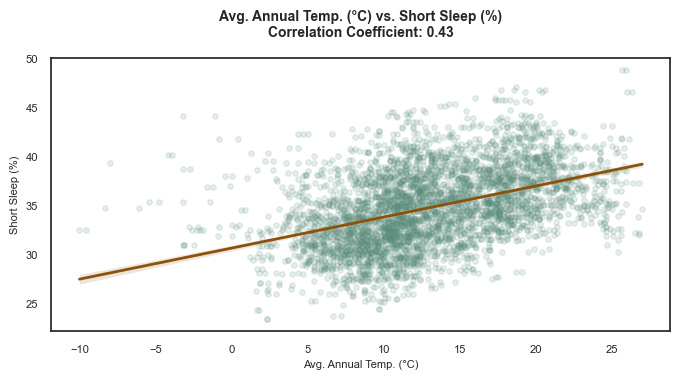

In [ ]:
top_pairs = [
    ('DT32', 'SLEEP'),
    ('PRCP', 'BPHIGH'),
    ('TAVG', 'SLEEP')
]


df_corr = df[weather_vars + health_vars].dropna()

sns.set(style="white", font_scale=1.1)

for x, y in top_pairs:
    plt.figure(figsize=(7, 4))
    
    sns.regplot(
        data=df_corr, x=x, y=y,
        scatter_kws={'alpha': 0.15, 's': 15, 'color': '#5b8e7d'},
        line_kws={'color': '#8c510a', 'lw': 2}
    )
    
    r_value = df_corr[x].corr(df_corr[y])
    
    plt.title(
        f"{rename_dict[x]} vs. {rename_dict[y]}\nCorrelation Coefficient: {r_value:.2f}",
        fontsize=10, weight='bold', pad=15
    )
    
    plt.xlabel(rename_dict[x], fontsize=8)
    plt.ylabel(rename_dict[y], fontsize=8)
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.tight_layout()
    plt.show()

The key takeaways are the following:
* More freezing days correlate with longer sleep.
* A higher annual precipitation correlates with higher blood pressure.
* A higher average annual temperature correlates with shorter sleep.

All correlations, however, are weak. 

## 5. Visualize bivariate relationships II: Health vs. socio-economic status

### 5.1. Compute a correlation matrix and plot the heatmap

We will recycle the health outcome variables from before, and we will also use some socioeconomic stressors:

* **median_household_income**
* **pct_bachelors_plus**
* **median_age**
* **pct_male**
* **pct_white**
* **pct_black**
* **pct_hispanic**

First, we define the socioeconomic variables.

In [9]:
socioecon_vars = [
    'median_household_income', 
    'pct_bachelors_plus', 
    'median_age',
    'pct_male',
    'pct_white',
    'pct_black',
    'pct_hispanic'
]

Then, we create a correlation matrix which runs a Pearson Correlation for each possible pair. We use `.dropna()` here to ensure we only correlate rows that have both weather and health data. In other words, `.dropna()` keeps only rows where _all_ 10 variables are non-missing.

In [10]:
corr_matrix_socioecon = df[socioecon_vars + health_vars].dropna().corr()
corr_subset_socioecon = corr_matrix_socioecon.loc[socioecon_vars, health_vars]

print('Shape of data set containing NAs:', df[health_vars + socioecon_vars].shape)
print('Shape of data set excluding NAs:', df[health_vars + socioecon_vars].dropna().shape)
print(corr_subset_socioecon)

Shape of data set containing NAs: (6646, 14)
Shape of data set excluding NAs: (5266, 14)
                          CASTHMA     SLEEP      COPD     MHLTH     PHLTH  \
median_household_income -0.220362 -0.268380 -0.668138 -0.275343 -0.534051   
pct_bachelors_plus      -0.159991 -0.394112 -0.633182 -0.223226 -0.622771   
median_age              -0.143955  0.043541 -0.268638 -0.134072 -0.168045   
pct_male                -0.104597 -0.091125 -0.072931 -0.058365  0.009117   
pct_white               -0.314960 -0.263557  0.041362 -0.479564 -0.282126   
pct_black                0.278901  0.221620  0.108092  0.333081  0.132919   
pct_hispanic            -0.266170 -0.040135 -0.195833 -0.139403  0.046166   

                           STROKE    BPHIGH  
median_household_income -0.651740 -0.538521  
pct_bachelors_plus      -0.618191 -0.482583  
median_age              -0.208874 -0.209516  
pct_male                -0.062566 -0.170645  
pct_white               -0.199069 -0.128887  
pct_black         

To visualize the relationships, we can create a heatmap, or, a "Weather-Health" map (retaining only correlations between weather and health variables, and not autocorrelations).

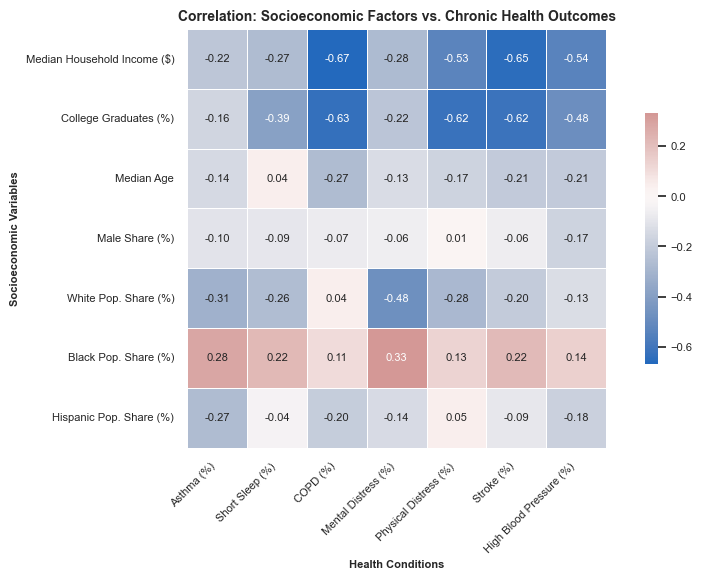

In [11]:
rename_dict.update({
    'median_household_income': 'Median Household Income ($)',
    'pct_bachelors_plus': 'College Graduates (%)',
    'median_age': 'Median Age',
    'pct_male': 'Male Share (%)',
    'pct_female': 'Female Share (%)',
    'pct_white': 'White Pop. Share (%)',
    'pct_black': 'Black Pop. Share (%)',
    'pct_hispanic': 'Hispanic Pop. Share (%)'
})

corr_matrix_socioecon = df[socioecon_vars + health_vars].dropna().corr().loc[socioecon_vars, health_vars]

corr_matrix_socioecon.index = [rename_dict.get(x, x) for x in corr_matrix_socioecon.index]
corr_matrix_socioecon.columns = [rename_dict.get(x, x) for x in corr_matrix_socioecon.columns]

plt.figure(figsize=(9, 6))

ax_socioecon = sns.heatmap(corr_matrix_socioecon, 
            annot=True,          
            fmt=".2f", 
            cmap='vlag',     
            center=0,
            square=True, 
            linewidths=.5,
            cbar_kws={"shrink": .6, "pad": 0.05}, 
            annot_kws={"size": 8})

plt.title("Correlation: Socioeconomic Factors vs. Chronic Health Outcomes", fontsize=10, weight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.xlabel("Health Conditions", fontsize=8, weight='bold')
plt.ylabel("Socioeconomic Variables", fontsize=8, weight='bold')

cbar = ax_socioecon.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

Inside the squares, we can see Pearson's correlation coefficient for each pair of variables.

Some moderate-to-high associations stand out, e.g., the negative relationship between median household income and COPD (%), the negative relationship between median household income and stroke (%), and the negative relationship between college graduates (%) and COPD (%).

That being said, most correlations are weak to moderate. 

### 5.2. Create scatter plots to visualize relationships

We check the relationship between gender split and the selected health outcomes.

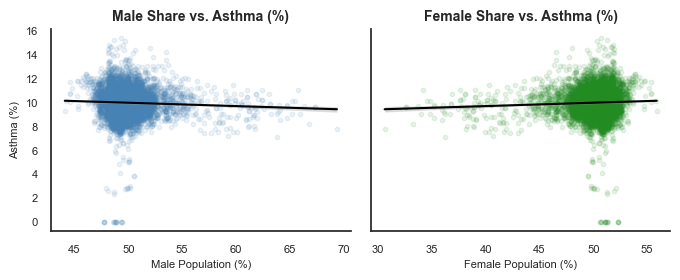

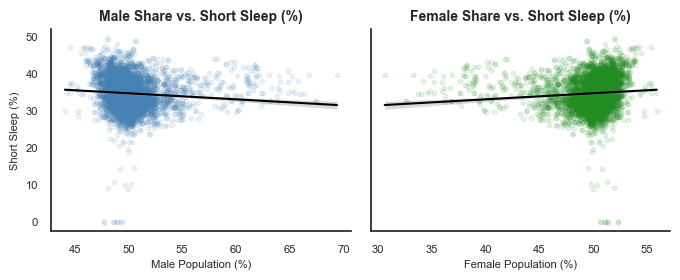

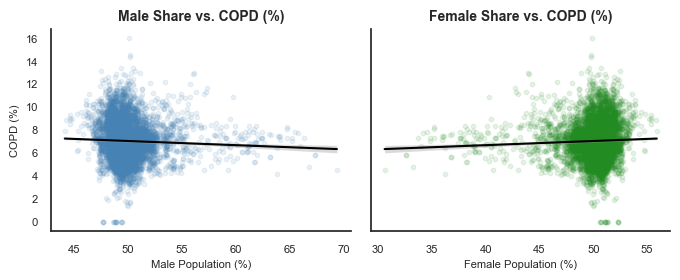

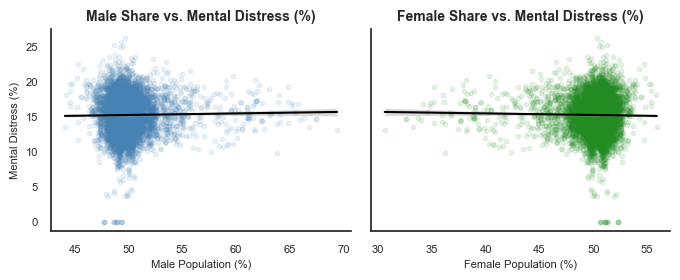

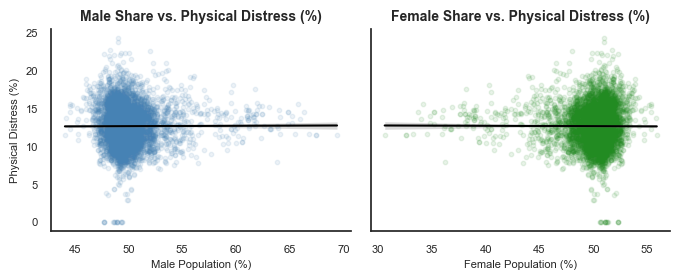

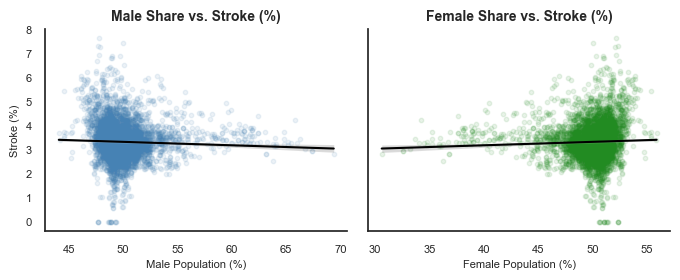

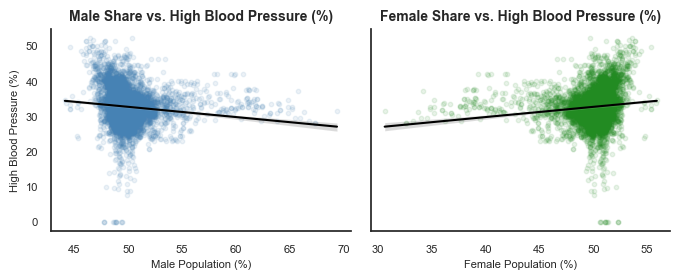

In [13]:
df_corr_socioec = df[socioecon_vars + health_vars].dropna()

for var in health_vars:
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

    pretty_name = rename_dict.get(var, var)

    sns.regplot(data=df, x='pct_male', y=var, 
                ax=ax1, color='steelblue', 
                scatter_kws={'alpha': 0.1, 's': 10}, 
                line_kws={'color': 'black', 'lw': 1.5})
    
    ax1.set_title(f"Male Share vs. {pretty_name}", fontsize=10, weight='bold')
    ax1.set_xlabel("Male Population (%)", fontsize=8)
    ax1.set_ylabel(f"{pretty_name}", fontsize=8)

    sns.regplot(data=df, x='pct_female', y=var, 
                ax=ax2, color='forestgreen', 
                scatter_kws={'alpha': 0.1, 's': 10}, 
                line_kws={'color': 'black', 'lw': 1.5})
    
    ax2.set_title(f"Female Share vs. {pretty_name}", fontsize=10, weight='bold')
    ax2.set_xlabel("Female Population (%)", fontsize=8)
    ax2.set_ylabel("", fontsize=8) 

    for ax in [ax1, ax2]:
        ax.tick_params(labelsize=8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

A higher female share is positively associated with asthma (%), short sleep (%), COPD (%), stroke (%), and high blood pressure (%). Gender seems to play a role, albeit weak to moderate, as far as health outcomes are concerned.